# Match Length From Moneyline

This notebook prepares the data foundation for a model that predicts tennis match length from pre-match moneyline odds.

Use the project `.venv` kernel so `google-cloud-bigquery` and project imports are available.

Tables in scope:
- `prizepicksanalytics.originations_tennis.oj_fixtures`
- `prizepicksanalytics.originations_tennis.oj_odds`

Setup goals:
- Establish a reliable BigQuery connection
- Inspect schema for both tables
- Profile coverage/quality with bounded queries (ATP + WTA)
- Explore `result_json` availability/shape for target engineering

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
from google.cloud import bigquery

pd.set_option('display.max_columns', None)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "injestion").exists() and (candidate / ".env").exists():
            return candidate
    raise RuntimeError("Could not find project root containing `injestion/` and `.env`.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from injestion.core.env import load_env

load_env()

FIXTURES_TABLE_ID = os.getenv(
    "BIGQUERY_ODDSJAM_FIXTURES_TABLE_ID",
    "prizepicksanalytics.originations_tennis.oj_fixtures",
)
ODDS_TABLE_ID = os.getenv(
    "BIGQUERY_ODDSJAM_ODDS_TABLE_ID",
    "prizepicksanalytics.originations_tennis.oj_odds",
)

MAX_BYTES_BILLED_GB = 30
MAX_BYTES_BILLED = MAX_BYTES_BILLED_GB * (1024**3)

bq_client = bigquery.Client(project="prizepicksanalytics")

print(f"Project root: {PROJECT_ROOT}")
print(f"Fixtures table: {FIXTURES_TABLE_ID}")
print(f"Odds table: {ODDS_TABLE_ID}")
print(f"Maximum bytes billed per query: {MAX_BYTES_BILLED_GB} GB")

Project root: /Users/matt.holden/Projects/tennis-origination
Fixtures table: prizepicksanalytics.originations_tennis.oj_fixtures
Odds table: prizepicksanalytics.originations_tennis.oj_odds
Maximum bytes billed per query: 30 GB


In [2]:
def run_query(query: str, *, params: list[bigquery.ScalarQueryParameter] | None = None) -> pd.DataFrame:
    job_config = bigquery.QueryJobConfig(maximum_bytes_billed=MAX_BYTES_BILLED)
    if params:
        job_config.query_parameters = params
    return bq_client.query(query, job_config=job_config).to_dataframe()


def dry_run_bytes(query: str) -> int:
    job_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
    job = bq_client.query(query, job_config=job_config)
    total_bytes = int(job.total_bytes_processed or 0)
    print(f"Estimated bytes processed: {total_bytes:,} ({total_bytes / (1024**3):.2f} GB)")
    return total_bytes


def table_parts(table_id: str) -> tuple[str, str, str]:
    project, dataset, table = table_id.split(".")
    return project, dataset, table

## 1) Schema introspection

Use metadata reads first (cheap) before touching the large odds table with full scans.

In [3]:
def schema_dataframe(table_id: str) -> pd.DataFrame:
    table = bq_client.get_table(table_id)
    rows = []
    for field in table.schema:
        rows.append(
            {
                "table": table.table_id,
                "column_name": field.name,
                "type": field.field_type,
                "mode": field.mode,
                "description": field.description,
            }
        )
    return pd.DataFrame(rows)


fixtures_schema_df = schema_dataframe(FIXTURES_TABLE_ID)
odds_schema_df = schema_dataframe(ODDS_TABLE_ID)

print("Fixtures schema")
display(fixtures_schema_df)

print("Odds schema")
display(odds_schema_df)

Fixtures schema


,table,column_name,type,mode,description
0,oj_fixtures,id,STRING,NULLABLE,None
1,oj_fixtures,numerical_id,INTEGER,NULLABLE,None
2,oj_fixtures,game_id,STRING,NULLABLE,None
3,oj_fixtures,start_date,TIMESTAMP,NULLABLE,None
4,oj_fixtures,home_team_display,STRING,NULLABLE,None
5,oj_fixtures,away_team_display,STRING,NULLABLE,None
6,oj_fixtures,status,STRING,NULLABLE,None
7,oj_fixtures,is_live,BOOLEAN,NULLABLE,None
8,oj_fixtures,season_type,STRING,NULLABLE,None
9,oj_fixtures,season_year,STRING,NULLABLE,None


Odds schema


,table,column_name,type,mode,description
0,oj_odds,fixture_id,STRING,NULLABLE,None
1,oj_odds,game_id,STRING,NULLABLE,None
2,oj_odds,home_competitor_names,STRING,REPEATED,None
3,oj_odds,home_competitor_ids,STRING,REPEATED,None
4,oj_odds,away_competitor_names,STRING,REPEATED,None
5,oj_odds,away_competitor_ids,STRING,REPEATED,None
6,oj_odds,status,STRING,NULLABLE,None
7,oj_odds,is_live,BOOLEAN,NULLABLE,None
8,oj_odds,season_type,STRING,NULLABLE,None
9,oj_odds,season_year,STRING,NULLABLE,None


In [4]:
fixtures_project, fixtures_dataset, fixtures_table = table_parts(FIXTURES_TABLE_ID)
odds_project, odds_dataset, odds_table = table_parts(ODDS_TABLE_ID)

fixtures_meta_query = f"""
SELECT
  table_id,
  row_count,
  size_bytes,
  TIMESTAMP_MILLIS(last_modified_time) AS last_modified_utc
FROM `{fixtures_project}.{fixtures_dataset}.__TABLES__`
WHERE table_id = @table_id
"""

odds_meta_query = f"""
SELECT
  table_id,
  row_count,
  size_bytes,
  TIMESTAMP_MILLIS(last_modified_time) AS last_modified_utc
FROM `{odds_project}.{odds_dataset}.__TABLES__`
WHERE table_id = @table_id
"""

fixtures_meta_df = run_query(
    fixtures_meta_query,
    params=[bigquery.ScalarQueryParameter("table_id", "STRING", fixtures_table)],
)
odds_meta_df = run_query(
    odds_meta_query,
    params=[bigquery.ScalarQueryParameter("table_id", "STRING", odds_table)],
)

display(fixtures_meta_df)
display(odds_meta_df)

,table_id,row_count,size_bytes,last_modified_utc
0,oj_fixtures,25990,22836235,2026-07-06 23:00:52.383000+00:00


,table_id,row_count,size_bytes,last_modified_utc
0,oj_odds,1910847,712756699,2026-07-08 04:27:17.158000+00:00


## 2) Fixtures profiling (ATP/WTA)

This checks match coverage and how often `result_json` is populated.

In [5]:
fixtures_profile_query = f"""
SELECT
  league_name,
  COUNT(*) AS fixture_rows,
  COUNTIF(result_json IS NOT NULL AND result_json != 'null' AND result_json != '{{}}') AS fixture_rows_with_result_json,
  COUNTIF(status = 'completed') AS completed_rows,
  MIN(start_date) AS min_start_date,
  MAX(start_date) AS max_start_date
FROM `{FIXTURES_TABLE_ID}`
WHERE league_name IN ('ATP', 'WTA')
GROUP BY league_name
ORDER BY league_name
"""

print("Dry run estimate for fixtures profile:")
dry_run_bytes(fixtures_profile_query)

fixtures_profile_df = run_query(fixtures_profile_query)
display(fixtures_profile_df)

Dry run estimate for fixtures profile:
Estimated bytes processed: 7,059,676 (0.01 GB)


,league_name,fixture_rows,fixture_rows_with_result_json,completed_rows,min_start_date,max_start_date
0,ATP,10723,9553,10499,2023-12-30 01:00:00+00:00,2026-07-08 10:00:00+00:00
1,WTA,15267,13847,14908,2023-12-29 01:30:00+00:00,2026-07-08 14:00:00+00:00


## 3) Odds profiling (moneyline only)

`oj_odds` is large, so we stay scoped to ATP/WTA + moneyline and aggregate before detailed sampling.

In [6]:
odds_moneyline_profile_query = f"""
SELECT
  league_name,
  COUNT(*) AS moneyline_rows,
  COUNT(DISTINCT fixture_id) AS fixtures_with_moneyline,
  COUNT(DISTINCT sportsbook) AS sportsbooks_seen,
  COUNTIF(closing_line_price IS NOT NULL) AS rows_with_closing_moneyline,
  COUNTIF(no_odds) AS no_odds_rows
FROM `{ODDS_TABLE_ID}`
WHERE league_name IN ('ATP', 'WTA')
  AND market = 'Moneyline'
GROUP BY league_name
ORDER BY league_name
"""

print("Dry run estimate for odds moneyline profile:")
dry_run_bytes(odds_moneyline_profile_query)

odds_moneyline_profile_df = run_query(odds_moneyline_profile_query)
display(odds_moneyline_profile_df)

Dry run estimate for odds moneyline profile:
Estimated bytes processed: 109,977,939 (0.10 GB)


,league_name,moneyline_rows,fixtures_with_moneyline,sportsbooks_seen,rows_with_closing_moneyline,no_odds_rows
0,ATP,136005,6514,14,132265,0
1,WTA,188985,9844,14,184389,0


In [7]:
moneyline_sample_query = f"""
SELECT
  fixture_id,
  league_name,
  sportsbook,
  selection,
  normalized_selection,
  closing_line_price,
  closing_line_points,
  status,
  no_odds
FROM `{ODDS_TABLE_ID}`
WHERE league_name IN ('ATP', 'WTA')
  AND market = 'Moneyline'
  AND closing_line_price IS NOT NULL
ORDER BY fixture_id, sportsbook
LIMIT 250
"""

moneyline_sample_df = run_query(moneyline_sample_query)
display(moneyline_sample_df.head())
print(f"Sample rows returned: {len(moneyline_sample_df)}")

,fixture_id,league_name,sportsbook,selection,normalized_selection,closing_line_price,closing_line_points,status,no_odds
0,0038CFAB1598,ATP,BetMGM,Joao Fonseca,joao_fonseca,250.0,NaN,completed,False
1,0038CFAB1598,ATP,BetMGM,Arthur Fils,arthur_fils,-350.0,NaN,completed,False
2,0038CFAB1598,ATP,BetRivers,Arthur Fils,arthur_fils,-375.0,NaN,completed,False
3,0038CFAB1598,ATP,BetRivers,Joao Fonseca,joao_fonseca,280.0,NaN,completed,False
4,0038CFAB1598,ATP,Bovada,Arthur Fils,arthur_fils,-375.0,NaN,completed,False


Sample rows returned: 250


## 4) Explore `result_json` for target engineering

This inspects how final-score payloads are stored and how often they are missing.

In [8]:
result_json_availability_query = f"""
SELECT
  league_name,
  COUNT(*) AS fixture_rows,
  COUNTIF(result_json IS NULL OR result_json = 'null' OR result_json = '{{}}') AS missing_result_json_rows,
  ROUND(
    SAFE_DIVIDE(
      COUNTIF(result_json IS NULL OR result_json = 'null' OR result_json = '{{}}'),
      COUNT(*)
    ) * 100,
    2
  ) AS missing_result_json_pct
FROM `{FIXTURES_TABLE_ID}`
WHERE league_name IN ('ATP', 'WTA')
GROUP BY league_name
ORDER BY league_name
"""

result_json_availability_df = run_query(result_json_availability_query)
display(result_json_availability_df)

result_json_samples_query = f"""
SELECT
  id AS fixture_id,
  league_name,
  start_date,
  status,
  result_json
FROM `{FIXTURES_TABLE_ID}`
WHERE league_name IN ('ATP', 'WTA')
  AND result_json IS NOT NULL
  AND result_json != 'null'
  AND result_json != '{{}}'
ORDER BY start_date DESC
LIMIT 5
"""

result_json_samples_df = run_query(result_json_samples_query)
display(result_json_samples_df)

,league_name,fixture_rows,missing_result_json_rows,missing_result_json_pct
0,ATP,10723,1170,10.91
1,WTA,15267,1420,9.30


,fixture_id,league_name,start_date,status,result_json
0,20260706E5F9BE6B,WTA,2026-07-07 16:10:00+00:00,unplayed,"{""scores"": null, ""in_play_data"": {""period"": ""0..."
1,20260706D9A9136D,WTA,2026-07-07 15:00:00+00:00,unplayed,"{""scores"": null, ""in_play_data"": {""period"": ""0..."
2,20260706C6F82C74,ATP,2026-07-06 19:45:00+00:00,live,"{""scores"": {""home"": {""total"": 0, ""periods"": {""..."
3,2026070682552784,ATP,2026-07-06 17:10:00+00:00,completed,"{""scores"": {""home"": {""total"": 3, ""periods"": {""..."
4,2026070693DEB245,WTA,2026-07-06 15:30:00+00:00,completed,"{""scores"": {""home"": {""total"": 2, ""periods"": {""..."


## 5) Build a model-ready starter dataset

This creates one row per fixture + selection with consensus closing moneyline features, joined to fixture metadata and preliminary targets parsed from `result_json` (`total_sets_from_result`, `total_games_from_periods`).

It also adds `best_of_sets` inferred from a combination of:
- observed set counts in `result_json`
- observed max set index (`period_4`/`period_5` implies best-of-5)
- consensus `Total Sets` line when available

In [9]:
MODEL_START_DATE = "2022-01-01"
MODEL_END_DATE = "2026-12-31"

model_starter_query = f"""
WITH fixture_base AS (
  SELECT
    id AS fixture_id,
    start_date,
    league_name,
    status,
    home_team_display,
    away_team_display,
    home_competitor_names,
    away_competitor_names,
    result_json,
    SAFE_CAST(JSON_VALUE(result_json, '$.scores.home.total') AS FLOAT64) AS home_sets_won,
    SAFE_CAST(JSON_VALUE(result_json, '$.scores.away.total') AS FLOAT64) AS away_sets_won,
    (
      SELECT SUM(SAFE_CAST(period_game_count AS FLOAT64))
      FROM UNNEST(
        REGEXP_EXTRACT_ALL(result_json, r'"period_[0-9]+"[[:space:]]*:[[:space:]]*([0-9]+(?:[.][0-9]+)?)')
      ) AS period_game_count
    ) AS total_games_from_periods
  FROM `{FIXTURES_TABLE_ID}`
  WHERE league_name IN ('ATP', 'WTA')
    AND status = 'completed'
    AND result_json IS NOT NULL
    AND result_json != 'null'
    AND result_json != '{{}}'
    AND DATE(start_date) BETWEEN @start_date AND @end_date
),
closing_moneylines AS (
  SELECT
    fixture_id,
    league_name,
    sportsbook,
    selection,
    normalized_selection,
    closing_line_price
  FROM `{ODDS_TABLE_ID}`
  WHERE market = 'Moneyline'
    AND league_name IN ('ATP', 'WTA')
    AND closing_line_price IS NOT NULL
    AND IFNULL(no_odds, FALSE) = FALSE
),
consensus_by_selection AS (
  SELECT
    fixture_id,
    league_name,
    COALESCE(NULLIF(normalized_selection, ''), NULLIF(selection, '')) AS selection_key,
    COUNT(*) AS contributing_rows,
    COUNT(DISTINCT sportsbook) AS contributing_sportsbooks,
    AVG(closing_line_price) AS avg_closing_moneyline,
    MIN(closing_line_price) AS min_closing_moneyline,
    MAX(closing_line_price) AS max_closing_moneyline
  FROM closing_moneylines
  GROUP BY fixture_id, league_name, selection_key
),
row_level AS (
  SELECT
    f.fixture_id,
    f.start_date,
    f.league_name,
    f.status,
    f.home_team_display,
    f.away_team_display,
    f.home_competitor_names,
    f.away_competitor_names,
    c.selection_key,
    c.contributing_rows,
    c.contributing_sportsbooks,
    c.avg_closing_moneyline,
    c.min_closing_moneyline,
    c.max_closing_moneyline,
    f.home_sets_won,
    f.away_sets_won,
    GREATEST(f.home_sets_won, f.away_sets_won) AS max_sets_won,
    (f.home_sets_won + f.away_sets_won) AS total_sets_from_result,
    f.total_games_from_periods,
    CASE
      WHEN GREATEST(f.home_sets_won, f.away_sets_won) = 2 THEN 'best_of_3'
      WHEN GREATEST(f.home_sets_won, f.away_sets_won) = 3 THEN 'best_of_5'
      ELSE 'unknown'
    END AS best_of_sets_raw,
    f.result_json
  FROM fixture_base f
  LEFT JOIN consensus_by_selection c
    ON c.fixture_id = f.fixture_id
),
fixture_best_of AS (
  SELECT
    fixture_id,
    CASE
      WHEN COUNTIF(best_of_sets_raw = 'best_of_5') > 0 THEN 'best_of_5'
      WHEN COUNTIF(best_of_sets_raw = 'best_of_3') > 0 THEN 'best_of_3'
      ELSE 'unknown'
    END AS fixture_best_of_sets
  FROM row_level
  GROUP BY fixture_id
)
SELECT
  r.fixture_id,
  r.start_date,
  r.league_name,
  r.status,
  r.home_team_display,
  r.away_team_display,
  r.home_competitor_names,
  r.away_competitor_names,
  r.selection_key,
  r.contributing_rows,
  r.contributing_sportsbooks,
  r.avg_closing_moneyline,
  r.home_sets_won,
  r.away_sets_won,
  r.max_sets_won,
  r.total_sets_from_result,
  r.total_games_from_periods,
  r.best_of_sets_raw,
  CASE
    WHEN r.best_of_sets_raw = 'unknown' AND fb.fixture_best_of_sets != 'unknown'
      THEN fb.fixture_best_of_sets
    ELSE r.best_of_sets_raw
  END AS best_of_sets,
  r.result_json
FROM row_level r
LEFT JOIN fixture_best_of fb
  ON fb.fixture_id = r.fixture_id
ORDER BY r.start_date DESC
"""

print("Dry run estimate for model starter query:")
dry_run_bytes(model_starter_query)

model_starter_df = run_query(
    model_starter_query,
    params=[
        bigquery.ScalarQueryParameter("start_date", "DATE", MODEL_START_DATE),
        bigquery.ScalarQueryParameter("end_date", "DATE", MODEL_END_DATE),
    ],
)

display(model_starter_df.head(5))
print(f"Total rows returned: {len(model_starter_df)}")
print(model_starter_df['best_of_sets'].value_counts(dropna=False))

Dry run estimate for model starter query:
Estimated bytes processed: 158,488,909 (0.15 GB)


,fixture_id,start_date,league_name,status,home_team_display,away_team_display,home_competitor_names,away_competitor_names,selection_key,contributing_rows,contributing_sportsbooks,avg_closing_moneyline,home_sets_won,away_sets_won,max_sets_won,total_sets_from_result,total_games_from_periods,best_of_sets_raw,best_of_sets,result_json
0,2026070682552784,2026-07-06 17:10:00+00:00,ATP,completed,Taylor Fritz,Alexander Bublik,[Taylor Fritz],[Alexander Bublik],alexander_bublik,12,12,191.416667,3.0,0.0,3.0,3.0,33.0,best_of_5,best_of_5,"{""scores"": {""home"": {""total"": 3, ""periods"": {""..."
1,2026070682552784,2026-07-06 17:10:00+00:00,ATP,completed,Taylor Fritz,Alexander Bublik,[Taylor Fritz],[Alexander Bublik],taylor_fritz,12,12,-234.666667,3.0,0.0,3.0,3.0,33.0,best_of_5,best_of_5,"{""scores"": {""home"": {""total"": 3, ""periods"": {""..."
2,20260706E3E7D7F0,2026-07-06 15:30:00+00:00,WTA,completed,Tiana Tian Deng,Kaitlin Quevedo,[Tiana Tian Deng],[Kaitlin Quevedo],kaitlin_quevedo,6,6,-3687.666667,0.0,2.0,2.0,2.0,17.0,best_of_3,best_of_3,"{""scores"": {""home"": {""total"": 0, ""periods"": {""..."
3,20260706E3E7D7F0,2026-07-06 15:30:00+00:00,WTA,completed,Tiana Tian Deng,Kaitlin Quevedo,[Tiana Tian Deng],[Kaitlin Quevedo],tiana_tian_deng,6,6,1108.000000,0.0,2.0,2.0,2.0,17.0,best_of_3,best_of_3,"{""scores"": {""home"": {""total"": 0, ""periods"": {""..."
4,2026070693DEB245,2026-07-06 15:30:00+00:00,WTA,completed,Francesca Curmi,Oceane Dodin,[Francesca Curmi],[Oceane Dodin],francesca_curmi,9,9,-232.777778,2.0,0.0,2.0,2.0,19.0,best_of_3,best_of_3,"{""scores"": {""home"": {""total"": 2, ""periods"": {""..."


Total rows returned: 38883
best_of_sets
best_of_3    35535
best_of_5     2106
unknown       1242
Name: count, dtype: int64


In [10]:
model_starter_clean_df = model_starter_df[~model_starter_df['avg_closing_moneyline'].isna()]

In [11]:
moneyline = model_starter_clean_df["avg_closing_moneyline"]
implied_win_prob = pd.Series(pd.NA, index=moneyline.index, dtype="Float64")

positive_mask = moneyline > 0
negative_mask = moneyline < 0

implied_win_prob.loc[positive_mask] = 100 / (moneyline.loc[positive_mask] + 100)
implied_win_prob.loc[negative_mask] = (-moneyline.loc[negative_mask]) / ((-moneyline.loc[negative_mask]) + 100)

model_starter_clean_df["avg_closing_moneyline_implied_win_prob"] = implied_win_prob
model_starter_clean_df["competitiveness_metric"] = (
    0.5 - model_starter_clean_df["avg_closing_moneyline_implied_win_prob"]
).abs()


def select_favorite_rows_per_fixture(
    df: pd.DataFrame,
    implied_prob_col: str = "avg_closing_moneyline_implied_win_prob",
) -> pd.DataFrame:
    """
    Keep one competitor row per fixture by selecting the higher implied win probability
    (favorite side), then attach favorite-side competitiveness features.
    """
    candidates = df.dropna(subset=[implied_prob_col]).copy()

    favorites = (
        candidates.sort_values(["fixture_id", implied_prob_col], ascending=[True, False])
        .drop_duplicates(subset=["fixture_id"], keep="first")
        .copy()
    )

    favorites["favorite_win_prob"] = favorites[implied_prob_col]
    favorites["favorite_competitiveness_metric"] = (
        0.5 - favorites["favorite_win_prob"]
    ).abs()
    return favorites


display(
    model_starter_clean_df[
        [
            "fixture_id",
            "selection_key",
            "avg_closing_moneyline",
            "avg_closing_moneyline_implied_win_prob",
            "competitiveness_metric",
            "best_of_sets",
        ]
    ].head(10)
)

print(
    "Rows with implied probability:",
    int(model_starter_clean_df["avg_closing_moneyline_implied_win_prob"].notna().sum()),
)
print(
    "Rows with competitiveness metric:",
    int(model_starter_clean_df["competitiveness_metric"].notna().sum()),
)
print("Total rows in model_starter_clean_df:", len(model_starter_clean_df))

/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_29931/2151323522.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_starter_clean_df["avg_closing_moneyline_implied_win_prob"] = implied_win_prob
/var/folders/wj/3h07_z2d5xg4t2fzhqx3f0j00000gp/T/ipykernel_29931/2151323522.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_starter_clean_df["competitiveness_metric"] = (


,fixture_id,selection_key,avg_closing_moneyline,avg_closing_moneyline_implied_win_prob,competitiveness_metric,best_of_sets
0,2026070682552784,alexander_bublik,191.416667,0.343151,0.156849,best_of_5
1,2026070682552784,taylor_fritz,-234.666667,0.701195,0.201195,best_of_5
2,20260706E3E7D7F0,kaitlin_quevedo,-3687.666667,0.973599,0.473599,best_of_3
3,20260706E3E7D7F0,tiana_tian_deng,1108.000000,0.082781,0.417219,best_of_3
4,2026070693DEB245,francesca_curmi,-232.777778,0.699499,0.199499,best_of_3
5,2026070693DEB245,oceane_dodin,173.444444,0.365705,0.134295,best_of_3
6,2026070694DA482A,arthur_fery,207.538462,0.325163,0.174837,best_of_5
7,2026070694DA482A,grigor_dimitrov,-255.615385,0.718797,0.218797,best_of_5
8,2026070673B8DDA2,linda_noskova,124.076923,0.446275,0.053725,best_of_3
9,2026070673B8DDA2,madison_keys,-149.833333,0.599733,0.099733,best_of_3


Rows with implied probability: 31433
Rows with competitiveness metric: 31433
Total rows in model_starter_clean_df: 31433


In [12]:
model_starter_clean_df['best_of_sets'].value_counts(dropna=False)

best_of_sets
best_of_3    28747
best_of_5     1714
unknown        972
Name: count, dtype: int64

## Data Exploration

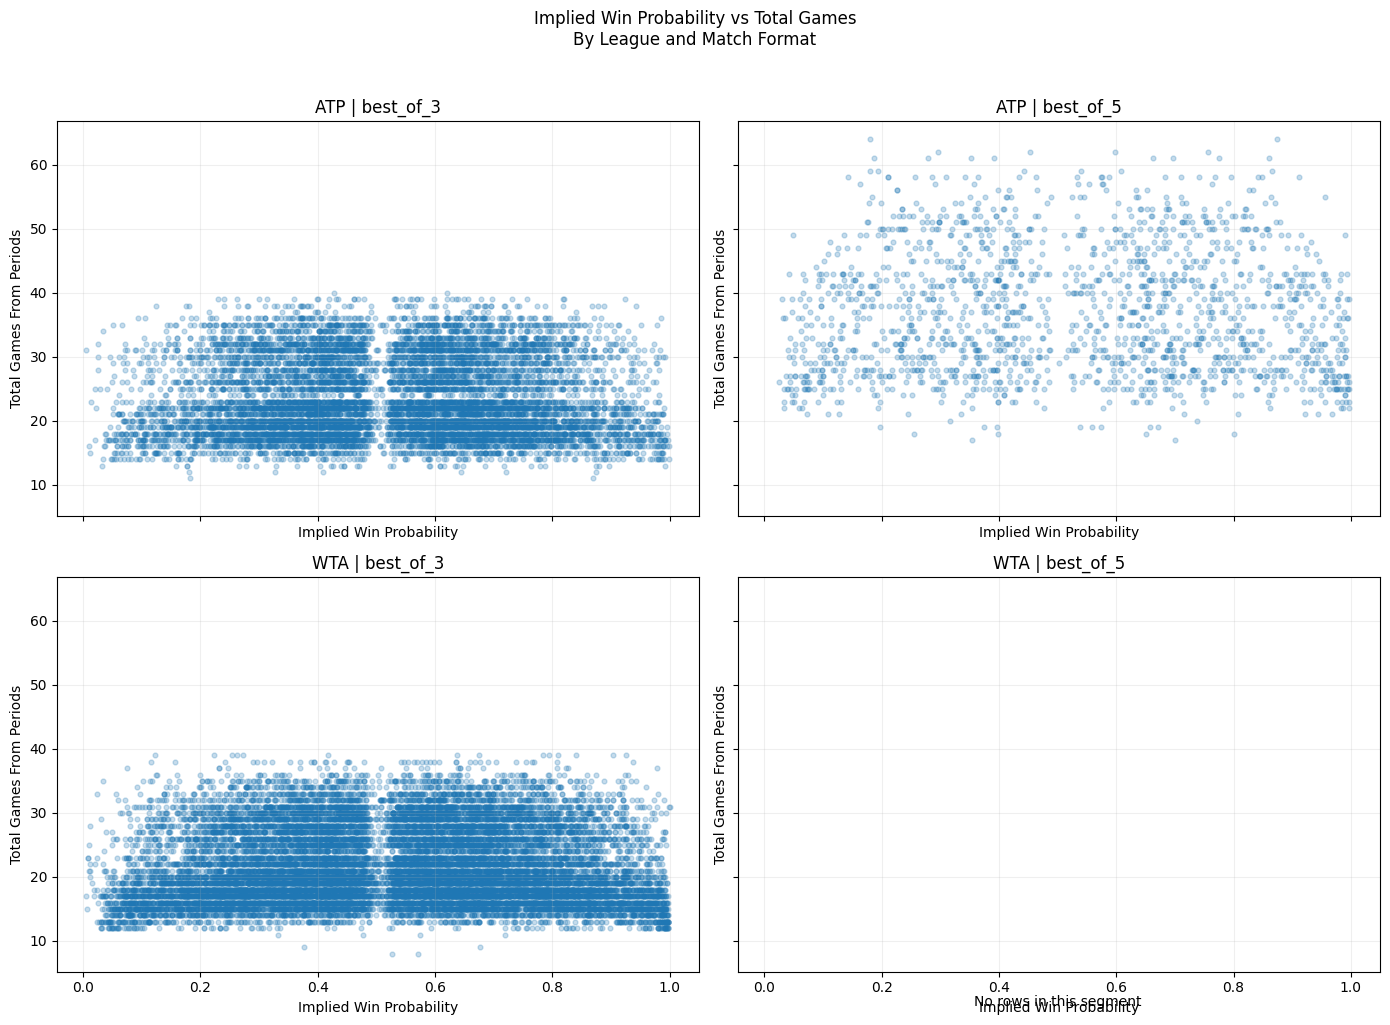

In [13]:
import matplotlib.pyplot as plt

plot_df = model_starter_clean_df[
    [
        "league_name",
        "best_of_sets",
        "avg_closing_moneyline_implied_win_prob",
        "total_games_from_periods",
    ]
].copy()

plot_df = plot_df.dropna(
    subset=["avg_closing_moneyline_implied_win_prob", "total_games_from_periods"]
)

segments = [
    ("ATP", "best_of_3"),
    ("ATP", "best_of_5"),
    ("WTA", "best_of_3"),
    ("WTA", "best_of_5"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

for ax, (league, best_of) in zip(axes.flatten(), segments):
    subset = plot_df[
        (plot_df["league_name"] == league) & (plot_df["best_of_sets"] == best_of)
    ]

    if subset.empty:
        ax.text(0.5, 0.5, "No rows in this segment", ha="center", va="center")
    else:
        ax.scatter(
            subset["avg_closing_moneyline_implied_win_prob"],
            subset["total_games_from_periods"],
            alpha=0.25,
            s=12,
        )

    ax.set_title(f"{league} | {best_of}")
    ax.set_xlabel("Implied Win Probability")
    ax.set_ylabel("Total Games From Periods")
    ax.grid(alpha=0.2)

plt.suptitle(
    "Implied Win Probability vs Total Games\nBy League and Match Format",
    y=1.02,
)
plt.tight_layout()
plt.show()

ATP best_of_3 fixture-level favorites: 5187
2-set matches: 3314 | 3-set matches: 1873


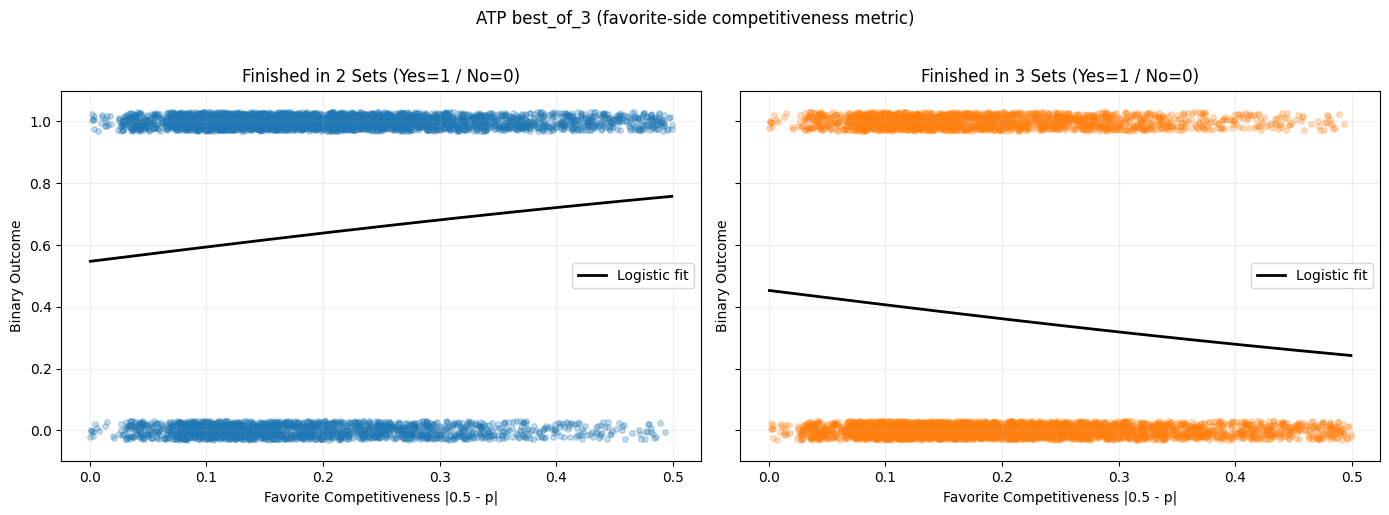

In [14]:
import numpy as np

try:
    from sklearn.linear_model import LogisticRegression
except ImportError as exc:
    raise ImportError(
        "scikit-learn is required for logistic regression plots. Install it in the notebook kernel environment."
    ) from exc

if "select_favorite_rows_per_fixture" not in globals():
    raise RuntimeError("Run the implied-probability feature engineering cell first.")

feature_col = "favorite_competitiveness_metric"

# Focus on men's best-of-3, then keep one favorite-side row per fixture.
atp_bo3_candidates = model_starter_clean_df[
    (model_starter_clean_df["league_name"] == "ATP")
    & (model_starter_clean_df["best_of_sets"] == "best_of_3")
].copy()
atp_bo3_candidates = atp_bo3_candidates.dropna(
    subset=["avg_closing_moneyline_implied_win_prob", "total_sets_from_result"]
)

atp_bo3_df = select_favorite_rows_per_fixture(atp_bo3_candidates)

# Keep valid best-of-3 outcomes only.
atp_bo3_df = atp_bo3_df[atp_bo3_df["total_sets_from_result"].isin([2, 3])].copy()

atp_bo3_df["finished_in_2_sets"] = (atp_bo3_df["total_sets_from_result"] == 2).astype(int)
atp_bo3_df["finished_in_3_sets"] = (atp_bo3_df["total_sets_from_result"] == 3).astype(int)

print(f"ATP best_of_3 fixture-level favorites: {len(atp_bo3_df)}")
print(
    "2-set matches:",
    int(atp_bo3_df["finished_in_2_sets"].sum()),
    "| 3-set matches:",
    int(atp_bo3_df["finished_in_3_sets"].sum()),
)

x = atp_bo3_df[feature_col].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

plot_specs = [
    ("finished_in_2_sets", "Finished in 2 Sets (Yes=1 / No=0)", "tab:blue"),
    ("finished_in_3_sets", "Finished in 3 Sets (Yes=1 / No=0)", "tab:orange"),
]

for ax, (target_col, title, color) in zip(axes, plot_specs):
    y = atp_bo3_df[target_col].to_numpy()

    # Scatter with slight vertical jitter to make binary points visible.
    rng = np.random.default_rng(42)
    y_jitter = y + rng.uniform(-0.03, 0.03, size=len(y))
    ax.scatter(x, y_jitter, alpha=0.25, s=16, color=color)

    # Fit logistic regression when both classes are present.
    if len(np.unique(y)) > 1:
        model = LogisticRegression(solver="lbfgs")
        model.fit(x.reshape(-1, 1), y)

        x_grid = np.linspace(x.min(), x.max(), 200)
        y_prob = model.predict_proba(x_grid.reshape(-1, 1))[:, 1]
        ax.plot(x_grid, y_prob, color="black", linewidth=2, label="Logistic fit")
        ax.legend(loc="best")
    else:
        ax.text(0.5, 0.9, "Only one class in segment", transform=ax.transAxes, ha="center")

    ax.set_title(title)
    ax.set_xlabel("Favorite Competitiveness |0.5 - p|")
    ax.set_ylabel("Binary Outcome")
    ax.set_ylim(-0.1, 1.1)
    ax.grid(alpha=0.2)

plt.suptitle("ATP best_of_3 (favorite-side competitiveness metric)", y=1.02)
plt.tight_layout()
plt.show()

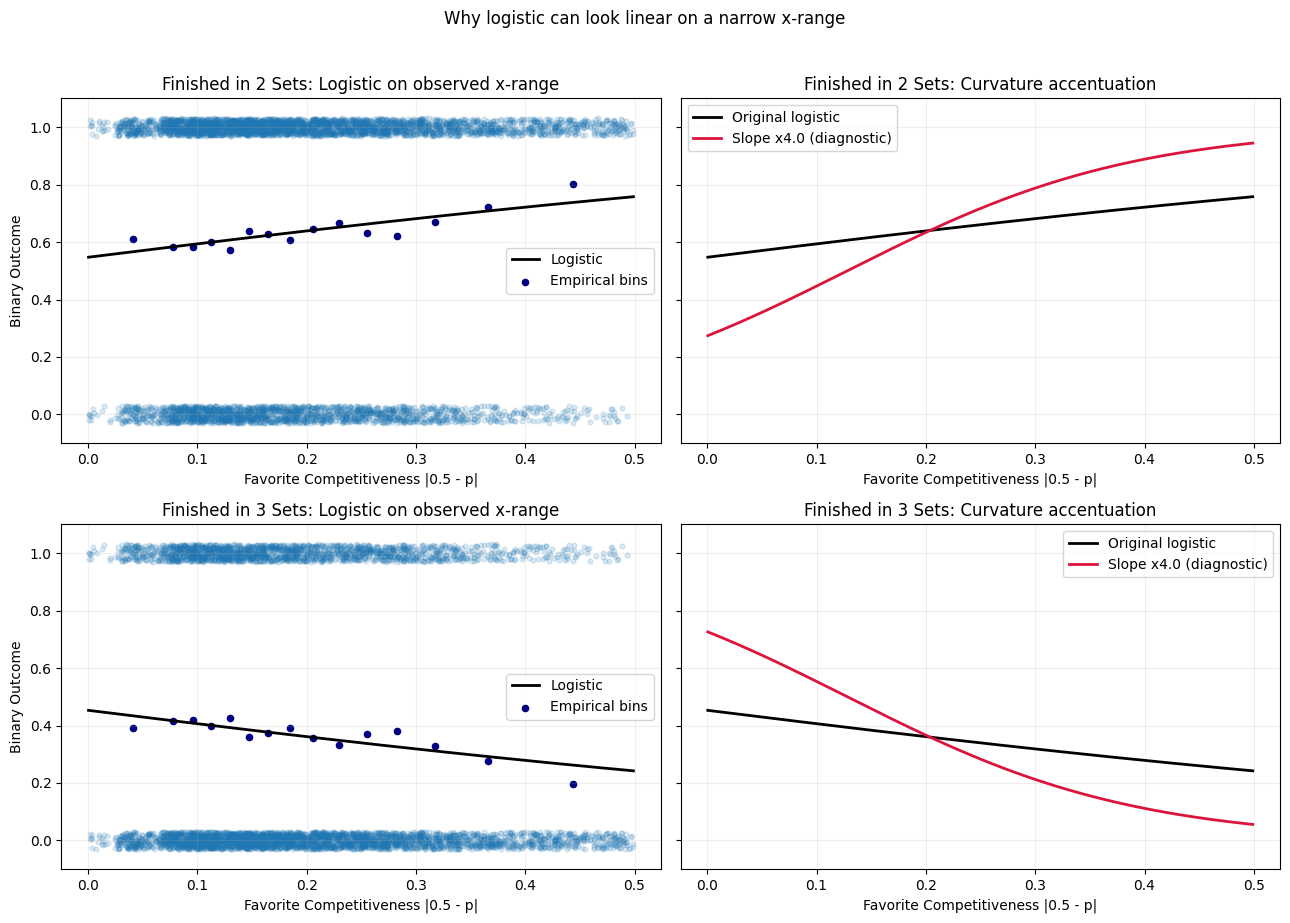

In [15]:
# Temporary diagnostic: accentuate logistic curvature for visibility.
if "atp_bo3_df" not in globals():
    raise RuntimeError("Run the ATP best_of_3 logistic cell first to create `atp_bo3_df`.")

if "LogisticRegression" not in globals():
    from sklearn.linear_model import LogisticRegression

feature_col = "favorite_competitiveness_metric"
accent_factor = 4.0
x = atp_bo3_df[feature_col].to_numpy()
x_grid_obs = np.linspace(x.min(), x.max(), 300)
plot_specs = [
    ("finished_in_2_sets", "Finished in 2 Sets"),
    ("finished_in_3_sets", "Finished in 3 Sets"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey="row")

for row_idx, (target_col, title) in enumerate(plot_specs):
    y = atp_bo3_df[target_col].to_numpy()

    model = LogisticRegression(solver="lbfgs")
    model.fit(x.reshape(-1, 1), y)

    beta = float(model.coef_[0][0])
    intercept = float(model.intercept_[0])

    # Standard logistic predictions.
    p_obs = model.predict_proba(x_grid_obs.reshape(-1, 1))[:, 1]

    # Accentuated curve: same midpoint, amplified slope (visual diagnostic only).
    x_center = float(x.mean())
    z_center = intercept + beta * x_center
    z_accent = z_center + accent_factor * beta * (x_grid_obs - x_center)
    p_accent = 1.0 / (1.0 + np.exp(-z_accent))

    # Empirical binned rates for context.
    tmp = atp_bo3_df[[feature_col, target_col]].copy()
    tmp["bin"] = pd.qcut(tmp[feature_col], q=15, duplicates="drop")
    binned = (
        tmp.groupby("bin", observed=False)
        .agg(
            x_center=(feature_col, "mean"),
            y_rate=(target_col, "mean"),
        )
        .dropna()
    )

    # Panel 1: observed range (can look almost linear).
    ax = axes[row_idx, 0]
    rng = np.random.default_rng(42)
    y_jitter = y + rng.uniform(-0.03, 0.03, size=len(y))
    ax.scatter(x, y_jitter, alpha=0.15, s=12, color="tab:blue")
    ax.plot(x_grid_obs, p_obs, color="black", linewidth=2, label="Logistic")
    ax.scatter(binned["x_center"], binned["y_rate"], color="navy", s=20, label="Empirical bins")
    ax.set_title(f"{title}: Logistic on observed x-range")
    ax.set_xlabel("Favorite Competitiveness |0.5 - p|")
    ax.set_ylabel("Binary Outcome")
    ax.set_ylim(-0.1, 1.1)
    ax.grid(alpha=0.2)
    ax.legend(loc="best")

    # Panel 2: amplified slope curve for visual intuition only.
    ax = axes[row_idx, 1]
    ax.plot(x_grid_obs, p_obs, color="black", linewidth=2, label="Original logistic")
    ax.plot(x_grid_obs, p_accent, color="crimson", linewidth=2, label=f"Slope x{accent_factor:.1f} (diagnostic)")
    ax.set_title(f"{title}: Curvature accentuation")
    ax.set_xlabel("Favorite Competitiveness |0.5 - p|")
    ax.set_ylim(-0.1, 1.1)
    ax.grid(alpha=0.2)
    ax.legend(loc="best")

plt.suptitle("Why logistic can look linear on a narrow x-range", y=1.02)
plt.tight_layout()
plt.show()

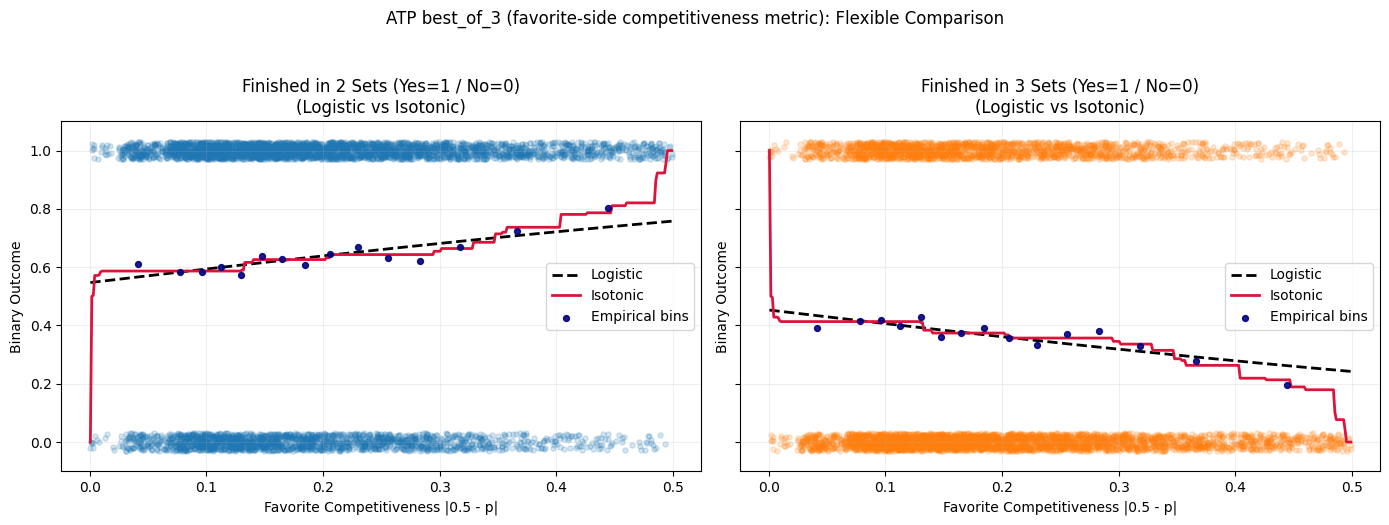

In [16]:
try:
    from sklearn.isotonic import IsotonicRegression
except ImportError as exc:
    raise ImportError(
        "scikit-learn is required for isotonic regression plots. Install it in the notebook kernel environment."
    ) from exc

if "atp_bo3_df" not in globals():
    raise RuntimeError("Run the logistic regression exploration cell first to create `atp_bo3_df`.")

feature_col = "favorite_competitiveness_metric"
x = atp_bo3_df[feature_col].to_numpy()
x_grid = np.linspace(x.min(), x.max(), 400)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

plot_specs = [
    ("finished_in_2_sets", "Finished in 2 Sets (Yes=1 / No=0)", "tab:blue", True),
    ("finished_in_3_sets", "Finished in 3 Sets (Yes=1 / No=0)", "tab:orange", False),
]

for ax, (target_col, title, color, increasing) in zip(axes, plot_specs):
    y = atp_bo3_df[target_col].to_numpy()

    rng = np.random.default_rng(42)
    y_jitter = y + rng.uniform(-0.03, 0.03, size=len(y))
    ax.scatter(x, y_jitter, alpha=0.18, s=14, color=color)

    # Logistic baseline (same model class as previous cell).
    if len(np.unique(y)) > 1:
        logistic_model = LogisticRegression(solver="lbfgs")
        logistic_model.fit(x.reshape(-1, 1), y)
        y_logistic = logistic_model.predict_proba(x_grid.reshape(-1, 1))[:, 1]
        ax.plot(x_grid, y_logistic, color="black", linestyle="--", linewidth=2, label="Logistic")

        # Isotonic regression: monotonic and more flexible than logistic.
        iso_model = IsotonicRegression(increasing=increasing, out_of_bounds="clip")
        iso_model.fit(x, y)
        y_iso = iso_model.predict(x_grid)
        ax.plot(x_grid, y_iso, color="crimson", linewidth=2, label="Isotonic")

        # Empirical bin means for quick visual sanity-check.
        tmp = atp_bo3_df[[feature_col, target_col]].copy()
        tmp["bin"] = pd.qcut(
            tmp[feature_col],
            q=15,
            duplicates="drop",
        )
        binned = (
            tmp.groupby("bin", observed=False)
            .agg(
                x_center=(feature_col, "mean"),
                y_rate=(target_col, "mean"),
                n=(target_col, "size"),
            )
            .dropna()
        )
        ax.scatter(
            binned["x_center"],
            binned["y_rate"],
            color="navy",
            s=18,
            alpha=0.9,
            label="Empirical bins",
            zorder=3,
        )

        ax.legend(loc="best")
    else:
        ax.text(0.5, 0.9, "Only one class in segment", transform=ax.transAxes, ha="center")

    ax.set_title(f"{title}\n(Logistic vs Isotonic)")
    ax.set_xlabel("Favorite Competitiveness |0.5 - p|")
    ax.set_ylabel("Binary Outcome")
    ax.set_ylim(-0.1, 1.1)
    ax.grid(alpha=0.2)

plt.suptitle("ATP best_of_3 (favorite-side competitiveness metric): Flexible Comparison", y=1.04)
plt.tight_layout()
plt.show()

ATP best_of_5 fixture-level favorites: 857
3-set: 375 | 4-set: 296 | 5-set: 186


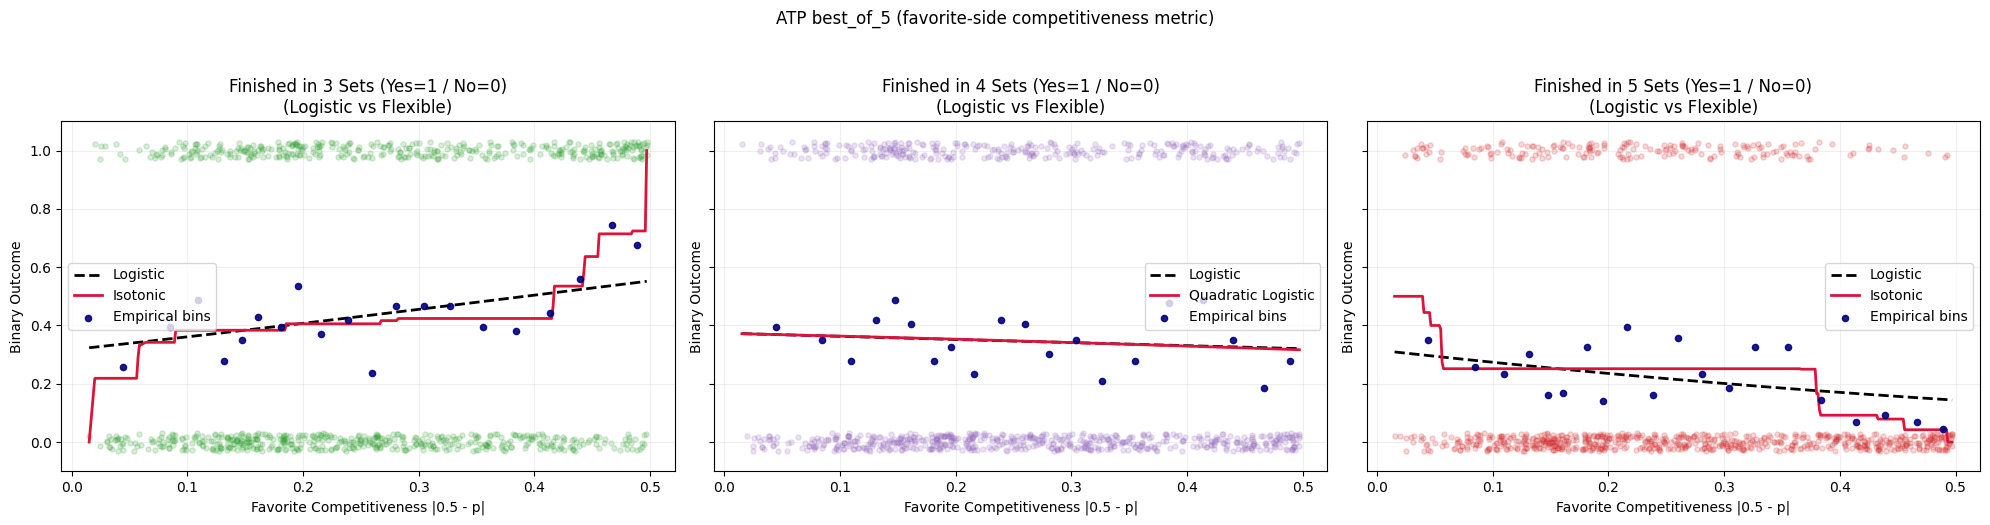

In [17]:
# ATP best_of_5: compare set-count completion probabilities vs favorite competitiveness.
try:
    from sklearn.isotonic import IsotonicRegression
    from sklearn.linear_model import LogisticRegression
except ImportError as exc:
    raise ImportError(
        "scikit-learn is required for this analysis. Install it in the notebook kernel environment."
    ) from exc

if "select_favorite_rows_per_fixture" not in globals():
    raise RuntimeError("Run the implied-probability feature engineering cell first.")

feature_col = "favorite_competitiveness_metric"

atp_bo5_candidates = model_starter_clean_df[
    (model_starter_clean_df["league_name"] == "ATP")
    & (model_starter_clean_df["best_of_sets"] == "best_of_5")
].copy()
atp_bo5_candidates = atp_bo5_candidates.dropna(
    subset=["avg_closing_moneyline_implied_win_prob", "total_sets_from_result"]
)

# Keep one favorite-side row per fixture so each match is counted once.
atp_bo5_df = select_favorite_rows_per_fixture(atp_bo5_candidates)

# Restrict to valid completed best-of-5 set counts.
atp_bo5_df = atp_bo5_df[atp_bo5_df["total_sets_from_result"].isin([3, 4, 5])].copy()

atp_bo5_df["finished_in_3_sets"] = (atp_bo5_df["total_sets_from_result"] == 3).astype(int)
atp_bo5_df["finished_in_4_sets"] = (atp_bo5_df["total_sets_from_result"] == 4).astype(int)
atp_bo5_df["finished_in_5_sets"] = (atp_bo5_df["total_sets_from_result"] == 5).astype(int)

print(f"ATP best_of_5 fixture-level favorites: {len(atp_bo5_df)}")
print(
    "3-set:", int(atp_bo5_df["finished_in_3_sets"].sum()),
    "| 4-set:", int(atp_bo5_df["finished_in_4_sets"].sum()),
    "| 5-set:", int(atp_bo5_df["finished_in_5_sets"].sum()),
)

x = atp_bo5_df[feature_col].to_numpy()
x_grid = np.linspace(x.min(), x.max(), 400)
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

plot_specs = [
    ("finished_in_3_sets", "Finished in 3 Sets (Yes=1 / No=0)", "tab:green", True),
    ("finished_in_4_sets", "Finished in 4 Sets (Yes=1 / No=0)", "tab:purple", None),
    ("finished_in_5_sets", "Finished in 5 Sets (Yes=1 / No=0)", "tab:red", False),
]

for ax, (target_col, title, color, monotonic_direction) in zip(axes, plot_specs):
    y = atp_bo5_df[target_col].to_numpy()

    rng = np.random.default_rng(42)
    y_jitter = y + rng.uniform(-0.03, 0.03, size=len(y))
    ax.scatter(x, y_jitter, alpha=0.18, s=14, color=color)

    if len(np.unique(y)) > 1:
        # Baseline logistic model (linear log-odds).
        logistic_model = LogisticRegression(solver="lbfgs")
        logistic_model.fit(x.reshape(-1, 1), y)
        y_logistic = logistic_model.predict_proba(x_grid.reshape(-1, 1))[:, 1]
        ax.plot(x_grid, y_logistic, color="black", linestyle="--", linewidth=2, label="Logistic")

        # Flexible comparison curve:
        # - For 3/5 sets: isotonic monotonic curve.
        # - For 4 sets: quadratic logistic (allows middle peak shape).
        if monotonic_direction is not None:
            flexible_model = IsotonicRegression(increasing=monotonic_direction, out_of_bounds="clip")
            flexible_model.fit(x, y)
            y_flexible = flexible_model.predict(x_grid)
            flexible_label = "Isotonic"
        else:
            x_quad = np.column_stack([x, x**2])
            x_grid_quad = np.column_stack([x_grid, x_grid**2])
            flexible_logit = LogisticRegression(solver="lbfgs")
            flexible_logit.fit(x_quad, y)
            y_flexible = flexible_logit.predict_proba(x_grid_quad)[:, 1]
            flexible_label = "Quadratic Logistic"

        ax.plot(x_grid, y_flexible, color="crimson", linewidth=2, label=flexible_label)

        # Empirical bin means for quick visual sanity-check.
        tmp = atp_bo5_df[[feature_col, target_col]].copy()
        tmp["bin"] = pd.qcut(
            tmp[feature_col],
            q=20,
            duplicates="drop",
        )
        binned = (
            tmp.groupby("bin", observed=False)
            .agg(
                x_center=(feature_col, "mean"),
                y_rate=(target_col, "mean"),
                n=(target_col, "size"),
            )
            .dropna()
        )
        ax.scatter(
            binned["x_center"],
            binned["y_rate"],
            color="navy",
            s=20,
            alpha=0.9,
            label="Empirical bins",
            zorder=3,
        )

        ax.legend(loc="best")
    else:
        ax.text(0.5, 0.9, "Only one class in segment", transform=ax.transAxes, ha="center")

    ax.set_title(f"{title}\n(Logistic vs Flexible)")
    ax.set_xlabel("Favorite Competitiveness |0.5 - p|")
    ax.set_ylabel("Binary Outcome")
    ax.set_ylim(-0.1, 1.1)
    ax.grid(alpha=0.2)

plt.suptitle("ATP best_of_5 (favorite-side competitiveness metric)", y=1.04)
plt.tight_layout()
plt.show()

## Demo: Moneyline to Expected Sets

Set a moneyline and match format, then compute:
- probability of each possible set count
- expected sets as a decimal (`sum(probability * set_count)`)

This demo uses logistic models fit on the same prepared subsets used in the exploration plots.

In [18]:
# Demo inputs
demo_moneyline = -100
demo_best_of = "best_of_5"  # use "best_of_3" or "best_of_5"

In [19]:
import numpy as np
from sklearn.linear_model import LogisticRegression


def american_to_implied_prob(moneyline_value: float) -> float:
    if moneyline_value == 0:
        raise ValueError("Moneyline cannot be 0.")
    if moneyline_value > 0:
        return 100.0 / (moneyline_value + 100.0)
    return (-moneyline_value) / ((-moneyline_value) + 100.0)


def fit_logit_probability_models(df: pd.DataFrame, feature_col: str, targets: dict[str, int]) -> dict[str, LogisticRegression]:
    models: dict[str, LogisticRegression] = {}
    x_train = df[feature_col].to_numpy().reshape(-1, 1)

    for target_name, set_count in targets.items():
        y_train = (df["total_sets_from_result"] == set_count).astype(int).to_numpy()

        if len(set(y_train.tolist())) < 2:
            continue

        model = LogisticRegression(solver="lbfgs")
        model.fit(x_train, y_train)
        models[target_name] = model

    return models


if "select_favorite_rows_per_fixture" not in globals():
    raise RuntimeError("Run the implied-probability feature engineering cell first.")

feature_col = "favorite_competitiveness_metric"

# Build universal modeling subsets (ATP + WTA), still split by best-of format.
universal_bo3_candidates = model_starter_clean_df[
    (model_starter_clean_df["league_name"].isin(["ATP", "WTA"]))
    & (model_starter_clean_df["best_of_sets"] == "best_of_3")
].copy()
universal_bo3_candidates = universal_bo3_candidates.dropna(
    subset=["avg_closing_moneyline_implied_win_prob", "total_sets_from_result"]
)
universal_bo3_demo_df = select_favorite_rows_per_fixture(universal_bo3_candidates)
universal_bo3_demo_df = universal_bo3_demo_df[
    universal_bo3_demo_df["total_sets_from_result"].isin([2, 3])
].copy()

universal_bo5_candidates = model_starter_clean_df[
    (model_starter_clean_df["league_name"].isin(["ATP", "WTA"]))
    & (model_starter_clean_df["best_of_sets"] == "best_of_5")
].copy()
universal_bo5_candidates = universal_bo5_candidates.dropna(
    subset=["avg_closing_moneyline_implied_win_prob", "total_sets_from_result"]
)
universal_bo5_demo_df = select_favorite_rows_per_fixture(universal_bo5_candidates)
universal_bo5_demo_df = universal_bo5_demo_df[
    universal_bo5_demo_df["total_sets_from_result"].isin([3, 4, 5])
].copy()

bo3_universal_models = fit_logit_probability_models(
    universal_bo3_demo_df,
    feature_col,
    {
        "2_sets": 2,
        "3_sets": 3,
    },
)
bo5_universal_models = fit_logit_probability_models(
    universal_bo5_demo_df,
    feature_col,
    {
        "3_sets": 3,
        "4_sets": 4,
        "5_sets": 5,
    },
)

print(f"Universal BO3 fixtures (ATP+WTA): {len(universal_bo3_demo_df)}")
print(f"Universal BO5 fixtures (ATP+WTA): {len(universal_bo5_demo_df)}")

side_implied_prob = american_to_implied_prob(float(demo_moneyline))
favorite_win_prob = max(side_implied_prob, 1.0 - side_implied_prob)
favorite_competitiveness_metric = abs(0.5 - favorite_win_prob)

if demo_best_of not in {"best_of_3", "best_of_5"}:
    raise ValueError("demo_best_of must be 'best_of_3' or 'best_of_5'.")

selected_models = (
    bo3_universal_models if demo_best_of == "best_of_3" else bo5_universal_models
)

x_input = np.array([[favorite_competitiveness_metric]])
raw_probs: dict[str, float] = {}
for key, model in selected_models.items():
    raw_probs[key] = float(model.predict_proba(x_input)[0, 1])

if not raw_probs:
    raise RuntimeError("No logistic models were available for the selected best-of format.")

prob_sum = sum(raw_probs.values())
if prob_sum <= 0:
    normalized_probs = {k: 1.0 / len(raw_probs) for k in raw_probs}
else:
    normalized_probs = {k: v / prob_sum for k, v in raw_probs.items()}

expected_sets = sum(float(k.split("_")[0]) * p for k, p in normalized_probs.items())

probability_output = (
    pd.DataFrame(
        {
            "set_count": [int(k.split("_")[0]) for k in normalized_probs],
            "probability": [normalized_probs[k] for k in normalized_probs],
            "raw_logistic_probability": [raw_probs[k] for k in normalized_probs],
        }
    )
    .sort_values("set_count")
    .reset_index(drop=True)
)

equation_output = []
for key, model in selected_models.items():
    beta_0 = float(model.intercept_[0])
    beta_1 = float(model.coef_[0][0])
    equation_output.append(
        {
            "set_count": int(key.split("_")[0]),
            "logit_equation": (
                f"logit(p) = {beta_0:.6f} + {beta_1:.6f} * favorite_competitiveness_metric"
            ),
        }
    )

equation_output_df = pd.DataFrame(equation_output).sort_values("set_count").reset_index(drop=True)

print(f"Demo moneyline: {demo_moneyline}")
print(f"Side implied win probability: {side_implied_prob:.4f}")
print(f"Favorite win probability used by model: {favorite_win_prob:.4f}")
print(f"Favorite competitiveness metric |0.5 - p|: {favorite_competitiveness_metric:.4f}")
print(f"Best-of format: {demo_best_of}")
print(f"Expected sets: {expected_sets:.4f}")

print("\nIndividual set-count probabilities")
display(probability_output)

print("Logistic equations used")
display(equation_output_df)

Demo moneyline: -100
Side implied win probability: 0.5000
Favorite win probability used by model: 0.5000
Favorite competitiveness metric |0.5 - p|: 0.0000
Best-of format: best_of_5
Expected sets: 3.9986

Individual set-count probabilities


,set_count,probability,raw_logistic_probability
0,3,0.315060,0.317076
1,4,0.371236,0.373612
2,5,0.313704,0.315712


Logistic equations used


,set_count,logit_equation
0,3,logit(p) = -0.767242 + 1.958626 * favorite_com...
1,4,logit(p) = -0.516753 + -0.471547 * favorite_co...
2,5,logit(p) = -0.773551 + -2.022302 * favorite_co...


## Spot Check: Logistic Models Using `refined_consensus`

Use the newly created refined consensus table (moneyline rows) to recreate the ATP best-of-3 and best-of-5 completion-probability spot-check plots.

In [23]:
from refined_tables import get_table_id

consensus_table_id = get_table_id("consensus")

consensus_moneyline_query = f"""
SELECT
  fixture_id,
  league_name,
  market,
  mode_best_of,
  total_sets_from_result,
  avg_closing_line_price,
  implied_win_prob,
  moneyline_competitiveness_metric
FROM `{consensus_table_id}`
WHERE LOWER(market) = 'moneyline'
  AND implied_win_prob IS NOT NULL
  AND moneyline_competitiveness_metric IS NOT NULL
  AND league_name IN ('ATP', 'WTA')
"""

consensus_moneyline_df = run_query(consensus_moneyline_query)

# Keep one favorite-side row per fixture for downstream training parity.
consensus_favorites_df = (
    consensus_moneyline_df.sort_values(["fixture_id", "implied_win_prob"], ascending=[True, False])
    .drop_duplicates(subset=["fixture_id"])
    .copy()
)

consensus_favorites_df = consensus_favorites_df.dropna(
    subset=[
        "mode_best_of",
        "total_sets_from_result",
        "moneyline_competitiveness_metric",
    ]
)

consensus_favorites_df["mode_best_of"] = consensus_favorites_df["mode_best_of"].astype(int)
consensus_favorites_df["total_sets_from_result"] = consensus_favorites_df["total_sets_from_result"].astype(int)

print(f"Consensus moneyline rows: {len(consensus_moneyline_df):,}")
print(f"Favorite rows by fixture: {len(consensus_favorites_df):,}")
print("Rows by mode_best_of")
print(consensus_favorites_df.value_counts("mode_best_of").sort_index())

consensus_favorites_df.head()

Consensus moneyline rows: 31,957
Favorite rows by fixture: 15,231
Rows by mode_best_of
mode_best_of
3    14374
5      857
Name: count, dtype: int64


,fixture_id,league_name,market,mode_best_of,total_sets_from_result,avg_closing_line_price,implied_win_prob,moneyline_competitiveness_metric
31628,0038CFAB1598,ATP,Moneyline,5,5,-391.875000,0.796696,0.296696
8322,0372116C47CB,ATP,Moneyline,3,2,-403.000000,0.801193,0.301193
23281,03F6F3F335E9,WTA,Moneyline,3,3,-567.272727,0.850136,0.350136
15846,061F7DDF065B,WTA,Moneyline,3,2,-146.777778,0.594777,0.094777
29106,063EC2E79B42,WTA,Moneyline,3,3,-278.600000,0.735869,0.235869


ATP best_of_3 refined fixtures: 5188
2-set: 3315 | 3-set: 1873


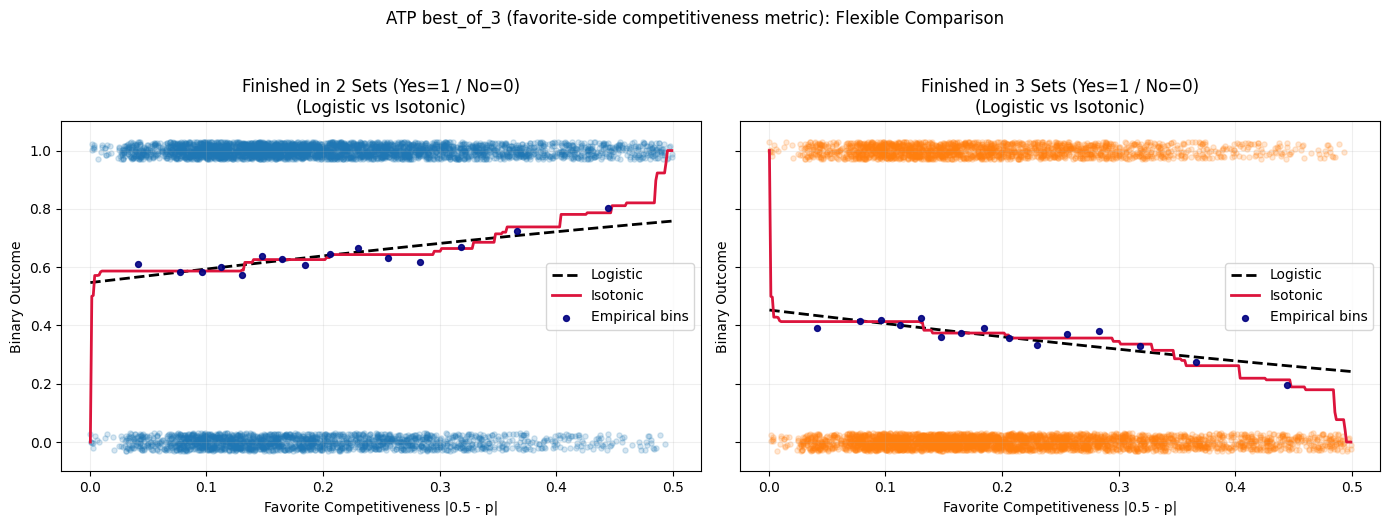

In [31]:
try:
    from sklearn.isotonic import IsotonicRegression
    from sklearn.linear_model import LogisticRegression
except ImportError as exc:
    raise ImportError(
        "scikit-learn is required for these spot-check plots. Install it in the notebook kernel environment."
    ) from exc

feature_col = "moneyline_competitiveness_metric"

# ATP best_of_3 spot check from refined consensus favorites.
atp_bo3_refined = consensus_favorites_df[
    (consensus_favorites_df["league_name"] == "ATP")
    & (consensus_favorites_df["mode_best_of"] == 3)
    & (consensus_favorites_df["total_sets_from_result"].isin([2, 3]))
].copy()

atp_bo3_refined["finished_in_2_sets"] = (atp_bo3_refined["total_sets_from_result"] == 2).astype(int)
atp_bo3_refined["finished_in_3_sets"] = (atp_bo3_refined["total_sets_from_result"] == 3).astype(int)

print(f"ATP best_of_3 refined fixtures: {len(atp_bo3_refined)}")
print(
    "2-set:", int(atp_bo3_refined["finished_in_2_sets"].sum()),
    "| 3-set:", int(atp_bo3_refined["finished_in_3_sets"].sum()),
)

x = atp_bo3_refined[feature_col].to_numpy()
x_grid = np.linspace(x.min(), x.max(), 400)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
plot_specs = [
    ("finished_in_2_sets", "Finished in 2 Sets (Yes=1 / No=0)", "tab:blue", True),
    ("finished_in_3_sets", "Finished in 3 Sets (Yes=1 / No=0)", "tab:orange", False),
]

for ax, (target_col, title, color, increasing) in zip(axes, plot_specs):
    y = atp_bo3_refined[target_col].to_numpy()

    rng = np.random.default_rng(42)
    y_jitter = y + rng.uniform(-0.03, 0.03, size=len(y))
    ax.scatter(x, y_jitter, alpha=0.18, s=14, color=color)

    if len(np.unique(y)) > 1:
        logistic_model = LogisticRegression(solver="lbfgs")
        logistic_model.fit(x.reshape(-1, 1), y)
        y_logistic = logistic_model.predict_proba(x_grid.reshape(-1, 1))[:, 1]
        ax.plot(x_grid, y_logistic, color="black", linestyle="--", linewidth=2, label="Logistic")

        iso_model = IsotonicRegression(increasing=increasing, out_of_bounds="clip")
        iso_model.fit(x, y)
        y_iso = iso_model.predict(x_grid)
        ax.plot(x_grid, y_iso, color="crimson", linewidth=2, label="Isotonic")

        tmp = atp_bo3_refined[[feature_col, target_col]].copy()
        tmp["bin"] = pd.qcut(tmp[feature_col], q=15, duplicates="drop")
        binned = (
            tmp.groupby("bin", observed=False)
            .agg(
                x_center=(feature_col, "mean"),
                y_rate=(target_col, "mean"),
                n=(target_col, "size"),
            )
            .dropna()
        )
        ax.scatter(
            binned["x_center"],
            binned["y_rate"],
            color="navy",
            s=18,
            alpha=0.9,
            label="Empirical bins",
            zorder=3,
        )
        ax.legend(loc="best")
    else:
        ax.text(0.5, 0.9, "Only one class in segment", transform=ax.transAxes, ha="center")

    ax.set_title(f"{title}\n(Logistic vs Isotonic)")
    ax.set_xlabel("Favorite Competitiveness |0.5 - p|")
    ax.set_ylabel("Binary Outcome")
    ax.set_ylim(-0.1, 1.1)
    ax.grid(alpha=0.2)

plt.suptitle("ATP best_of_3 (favorite-side competitiveness metric): Flexible Comparison", y=1.04)
plt.tight_layout()
plt.show()

ATP best_of_5 refined fixtures: 857
3-set: 375 | 4-set: 296 | 5-set: 186


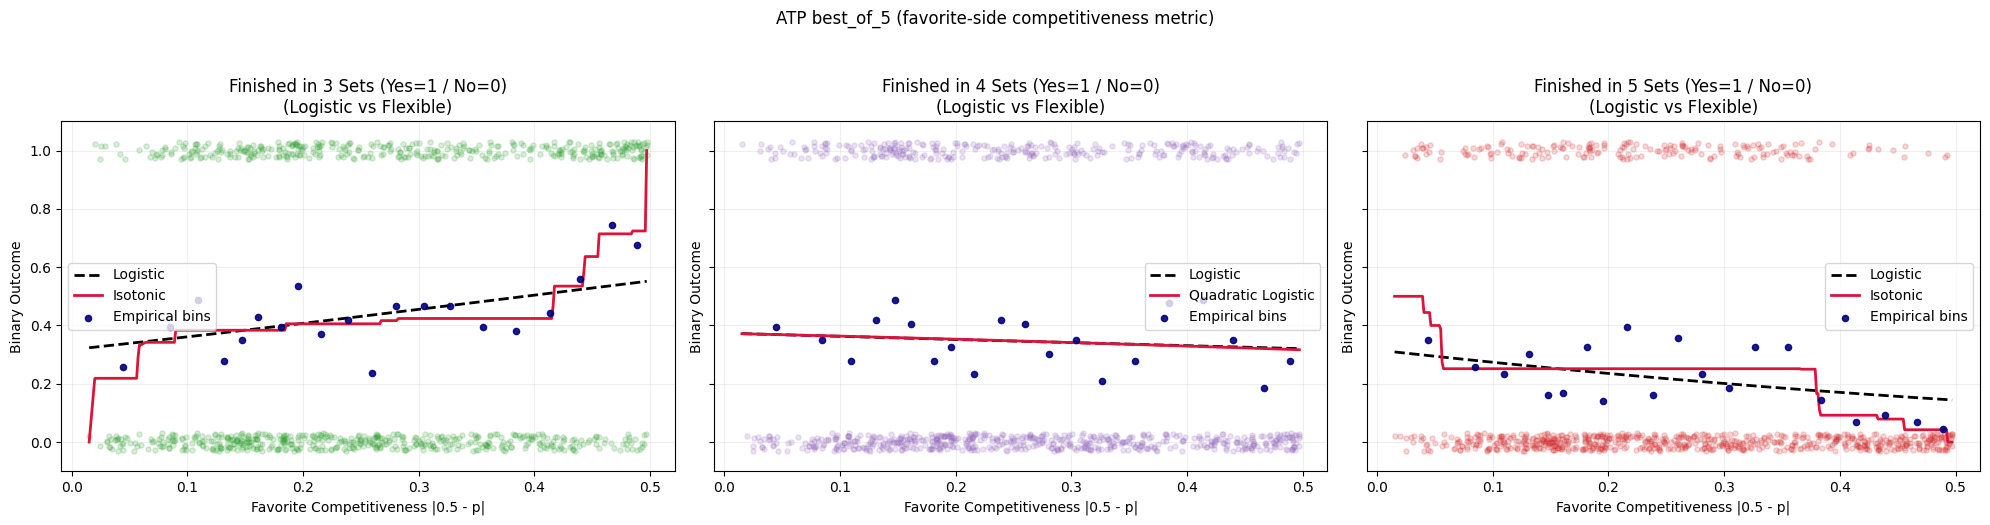

In [32]:
# ATP best_of_5 spot check from refined consensus favorites.
atp_bo5_refined = consensus_favorites_df[
    (consensus_favorites_df["league_name"] == "ATP")
    & (consensus_favorites_df["mode_best_of"] == 5)
    & (consensus_favorites_df["total_sets_from_result"].isin([3, 4, 5]))
].copy()

atp_bo5_refined["finished_in_3_sets"] = (atp_bo5_refined["total_sets_from_result"] == 3).astype(int)
atp_bo5_refined["finished_in_4_sets"] = (atp_bo5_refined["total_sets_from_result"] == 4).astype(int)
atp_bo5_refined["finished_in_5_sets"] = (atp_bo5_refined["total_sets_from_result"] == 5).astype(int)

print(f"ATP best_of_5 refined fixtures: {len(atp_bo5_refined)}")
print(
    "3-set:", int(atp_bo5_refined["finished_in_3_sets"].sum()),
    "| 4-set:", int(atp_bo5_refined["finished_in_4_sets"].sum()),
    "| 5-set:", int(atp_bo5_refined["finished_in_5_sets"].sum()),
)

x = atp_bo5_refined[feature_col].to_numpy()
x_grid = np.linspace(x.min(), x.max(), 400)
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

plot_specs = [
    ("finished_in_3_sets", "Finished in 3 Sets (Yes=1 / No=0)", "tab:green", True),
    ("finished_in_4_sets", "Finished in 4 Sets (Yes=1 / No=0)", "tab:purple", None),
    ("finished_in_5_sets", "Finished in 5 Sets (Yes=1 / No=0)", "tab:red", False),
]

for ax, (target_col, title, color, monotonic_direction) in zip(axes, plot_specs):
    y = atp_bo5_refined[target_col].to_numpy()

    rng = np.random.default_rng(42)
    y_jitter = y + rng.uniform(-0.03, 0.03, size=len(y))
    ax.scatter(x, y_jitter, alpha=0.18, s=14, color=color)

    if len(np.unique(y)) > 1:
        logistic_model = LogisticRegression(solver="lbfgs")
        logistic_model.fit(x.reshape(-1, 1), y)
        y_logistic = logistic_model.predict_proba(x_grid.reshape(-1, 1))[:, 1]
        ax.plot(x_grid, y_logistic, color="black", linestyle="--", linewidth=2, label="Logistic")

        if monotonic_direction is not None:
            flexible_model = IsotonicRegression(increasing=monotonic_direction, out_of_bounds="clip")
            flexible_model.fit(x, y)
            y_flexible = flexible_model.predict(x_grid)
            flexible_label = "Isotonic"
        else:
            x_quad = np.column_stack([x, x**2])
            x_grid_quad = np.column_stack([x_grid, x_grid**2])
            flexible_logit = LogisticRegression(solver="lbfgs")
            flexible_logit.fit(x_quad, y)
            y_flexible = flexible_logit.predict_proba(x_grid_quad)[:, 1]
            flexible_label = "Quadratic Logistic"

        ax.plot(x_grid, y_flexible, color="crimson", linewidth=2, label=flexible_label)

        tmp = atp_bo5_refined[[feature_col, target_col]].copy()
        tmp["bin"] = pd.qcut(tmp[feature_col], q=20, duplicates="drop")
        binned = (
            tmp.groupby("bin", observed=False)
            .agg(
                x_center=(feature_col, "mean"),
                y_rate=(target_col, "mean"),
                n=(target_col, "size"),
            )
            .dropna()
        )
        ax.scatter(
            binned["x_center"],
            binned["y_rate"],
            color="navy",
            s=20,
            alpha=0.9,
            label="Empirical bins",
            zorder=3,
        )

        ax.legend(loc="best")
    else:
        ax.text(0.5, 0.9, "Only one class in segment", transform=ax.transAxes, ha="center")

    ax.set_title(f"{title}\n(Logistic vs Flexible)")
    ax.set_xlabel("Favorite Competitiveness |0.5 - p|")
    ax.set_ylabel("Binary Outcome")
    ax.set_ylim(-0.1, 1.1)
    ax.grid(alpha=0.2)

plt.suptitle("ATP best_of_5 (favorite-side competitiveness metric)", y=1.04)
plt.tight_layout()
plt.show()

WTA best_of_3 refined fixtures: 9185
2-set: 6130 | 3-set: 3055


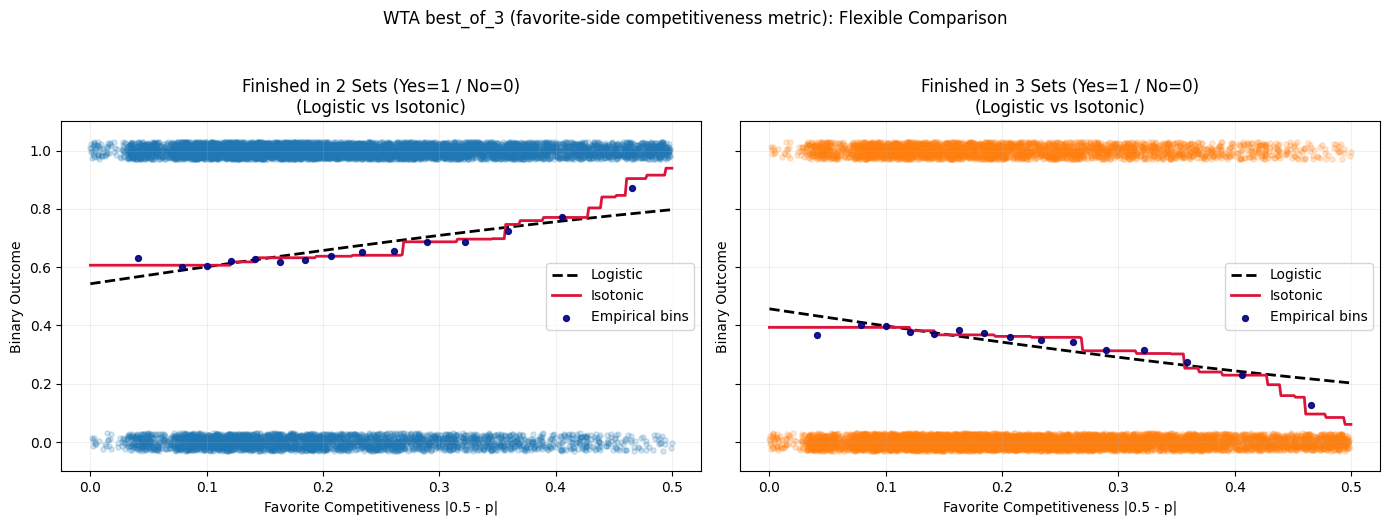

In [33]:
# WTA best_of_3 spot check from refined consensus favorites.
wta_bo3_refined = consensus_favorites_df[
    (consensus_favorites_df["league_name"] == "WTA")
    & (consensus_favorites_df["mode_best_of"] == 3)
    & (consensus_favorites_df["total_sets_from_result"].isin([2, 3]))
].copy()

wta_bo3_refined["finished_in_2_sets"] = (wta_bo3_refined["total_sets_from_result"] == 2).astype(int)
wta_bo3_refined["finished_in_3_sets"] = (wta_bo3_refined["total_sets_from_result"] == 3).astype(int)

print(f"WTA best_of_3 refined fixtures: {len(wta_bo3_refined)}")
print(
    "2-set:", int(wta_bo3_refined["finished_in_2_sets"].sum()),
    "| 3-set:", int(wta_bo3_refined["finished_in_3_sets"].sum()),
)

x = wta_bo3_refined[feature_col].to_numpy()
x_grid = np.linspace(x.min(), x.max(), 400)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
plot_specs = [
    ("finished_in_2_sets", "Finished in 2 Sets (Yes=1 / No=0)", "tab:blue", True),
    ("finished_in_3_sets", "Finished in 3 Sets (Yes=1 / No=0)", "tab:orange", False),
]

for ax, (target_col, title, color, increasing) in zip(axes, plot_specs):
    y = wta_bo3_refined[target_col].to_numpy()

    rng = np.random.default_rng(42)
    y_jitter = y + rng.uniform(-0.03, 0.03, size=len(y))
    ax.scatter(x, y_jitter, alpha=0.18, s=14, color=color)

    if len(np.unique(y)) > 1:
        logistic_model = LogisticRegression(solver="lbfgs")
        logistic_model.fit(x.reshape(-1, 1), y)
        y_logistic = logistic_model.predict_proba(x_grid.reshape(-1, 1))[:, 1]
        ax.plot(x_grid, y_logistic, color="black", linestyle="--", linewidth=2, label="Logistic")

        iso_model = IsotonicRegression(increasing=increasing, out_of_bounds="clip")
        iso_model.fit(x, y)
        y_iso = iso_model.predict(x_grid)
        ax.plot(x_grid, y_iso, color="crimson", linewidth=2, label="Isotonic")

        tmp = wta_bo3_refined[[feature_col, target_col]].copy()
        tmp["bin"] = pd.qcut(tmp[feature_col], q=15, duplicates="drop")
        binned = (
            tmp.groupby("bin", observed=False)
            .agg(
                x_center=(feature_col, "mean"),
                y_rate=(target_col, "mean"),
                n=(target_col, "size"),
            )
            .dropna()
        )
        ax.scatter(
            binned["x_center"],
            binned["y_rate"],
            color="navy",
            s=18,
            alpha=0.9,
            label="Empirical bins",
            zorder=3,
        )
        ax.legend(loc="best")
    else:
        ax.text(0.5, 0.9, "Only one class in segment", transform=ax.transAxes, ha="center")

    ax.set_title(f"{title}\n(Logistic vs Isotonic)")
    ax.set_xlabel("Favorite Competitiveness |0.5 - p|")
    ax.set_ylabel("Binary Outcome")
    ax.set_ylim(-0.1, 1.1)
    ax.grid(alpha=0.2)

plt.suptitle("WTA best_of_3 (favorite-side competitiveness metric): Flexible Comparison", y=1.04)
plt.tight_layout()
plt.show()

Combined ATP+WTA best_of_3 refined fixtures: 14373
league_name
WTA    9185
ATP    5188
Name: count, dtype: int64
2-set: 9445 | 3-set: 4928


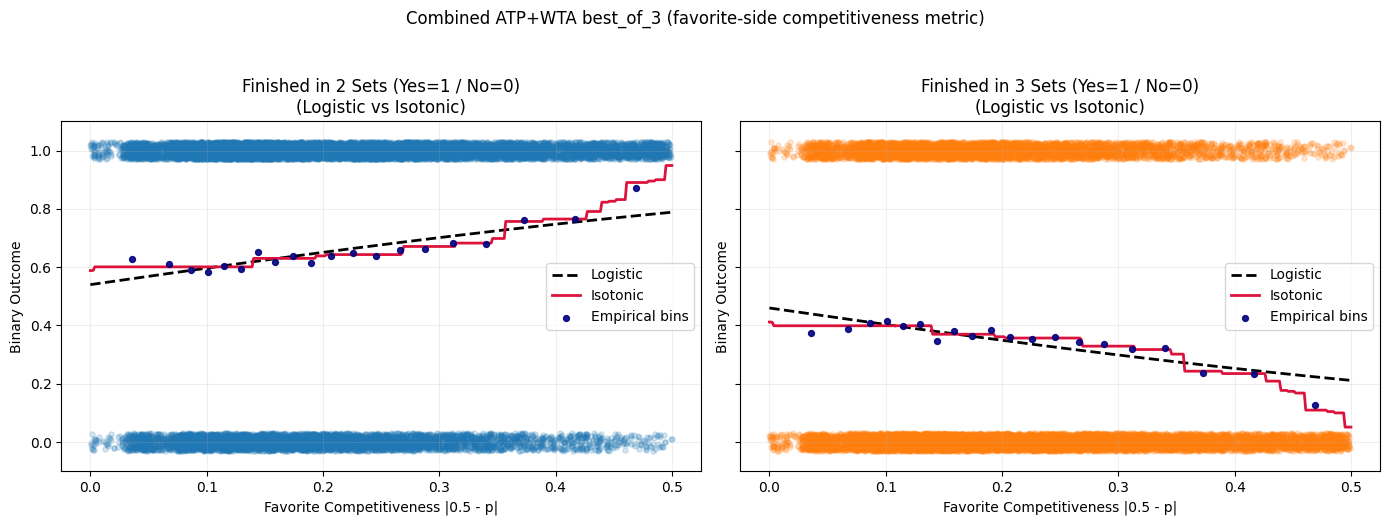

In [34]:
# Combined ATP + WTA best_of_3 spot check from refined consensus favorites.
combined_bo3_refined = consensus_favorites_df[
    (consensus_favorites_df["league_name"].isin(["ATP", "WTA"]))
    & (consensus_favorites_df["mode_best_of"] == 3)
    & (consensus_favorites_df["total_sets_from_result"].isin([2, 3]))
].copy()

combined_bo3_refined["finished_in_2_sets"] = (combined_bo3_refined["total_sets_from_result"] == 2).astype(int)
combined_bo3_refined["finished_in_3_sets"] = (combined_bo3_refined["total_sets_from_result"] == 3).astype(int)

print(f"Combined ATP+WTA best_of_3 refined fixtures: {len(combined_bo3_refined)}")
print(combined_bo3_refined["league_name"].value_counts())
print(
    "2-set:", int(combined_bo3_refined["finished_in_2_sets"].sum()),
    "| 3-set:", int(combined_bo3_refined["finished_in_3_sets"].sum()),
)

x = combined_bo3_refined[feature_col].to_numpy()
x_grid = np.linspace(x.min(), x.max(), 400)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
plot_specs = [
    ("finished_in_2_sets", "Finished in 2 Sets (Yes=1 / No=0)", "tab:blue", True),
    ("finished_in_3_sets", "Finished in 3 Sets (Yes=1 / No=0)", "tab:orange", False),
]

for ax, (target_col, title, color, increasing) in zip(axes, plot_specs):
    y = combined_bo3_refined[target_col].to_numpy()

    rng = np.random.default_rng(42)
    y_jitter = y + rng.uniform(-0.03, 0.03, size=len(y))
    ax.scatter(x, y_jitter, alpha=0.18, s=14, color=color)

    if len(np.unique(y)) > 1:
        logistic_model = LogisticRegression(solver="lbfgs")
        logistic_model.fit(x.reshape(-1, 1), y)
        y_logistic = logistic_model.predict_proba(x_grid.reshape(-1, 1))[:, 1]
        ax.plot(x_grid, y_logistic, color="black", linestyle="--", linewidth=2, label="Logistic")

        iso_model = IsotonicRegression(increasing=increasing, out_of_bounds="clip")
        iso_model.fit(x, y)
        y_iso = iso_model.predict(x_grid)
        ax.plot(x_grid, y_iso, color="crimson", linewidth=2, label="Isotonic")

        tmp = combined_bo3_refined[[feature_col, target_col]].copy()
        tmp["bin"] = pd.qcut(tmp[feature_col], q=20, duplicates="drop")
        binned = (
            tmp.groupby("bin", observed=False)
            .agg(
                x_center=(feature_col, "mean"),
                y_rate=(target_col, "mean"),
                n=(target_col, "size"),
            )
            .dropna()
        )
        ax.scatter(
            binned["x_center"],
            binned["y_rate"],
            color="navy",
            s=18,
            alpha=0.9,
            label="Empirical bins",
            zorder=3,
        )
        ax.legend(loc="best")
    else:
        ax.text(0.5, 0.9, "Only one class in segment", transform=ax.transAxes, ha="center")

    ax.set_title(f"{title}\n(Logistic vs Isotonic)")
    ax.set_xlabel("Favorite Competitiveness |0.5 - p|")
    ax.set_ylabel("Binary Outcome")
    ax.set_ylim(-0.1, 1.1)
    ax.grid(alpha=0.2)

plt.suptitle("Combined ATP+WTA best_of_3 (favorite-side competitiveness metric)", y=1.04)
plt.tight_layout()
plt.show()